## Code for generating the curtain composites for the model data
Define model domain based on wind path

In [1]:
import xarray as xr #
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import wrf
import pandas as pd
import time, os
import netCDF4 as nc
import pyproj
from scipy.spatial import cKDTree
from datetime import datetime
import matplotlib as mpl
import matplotlib.lines as mlines
from metpy.calc import wind_direction
from metpy.units import units

from functions import get_bounds, clip_model_to_flight, clip_model_to_flight_light, select_model_domain,ice_liq_model, phase_percent, get_modis_data, get_sea_ice_data
from func_comp_plot import plot_heatmap_ax, closest_idx, sample_var
from composite_utils import create_distribution_df
from func_dist import get_winddir, step_against_wind, step_with_wind, get_lon_lat_for_steps_downwind, get_lon_lat_for_steps_upwind

In [2]:
# Paths and files

modelpath = '/nird/datapeak/NS9600K/brittsc/250916_Longer_Arctic_simulation/WRF_output/'
mediumfiles = sorted([modelpath + file for file in os.listdir(modelpath) if file.split('_')[-4].startswith('me') and file.split('_')[-3] == 'd02'],
                     key=lambda f: datetime.strptime(f.split('_')[-2] + '_' + f.split('_')[-1], "%Y-%m-%d_%H:%M:%S"))
highresfiles = sorted([modelpath + file for file in os.listdir(modelpath) if file.split('_')[-4].startswith('hi') and file.split('_')[-3] == 'd02'],
                     key=lambda f: datetime.strptime(f.split('_')[-2] + '_' + f.split('_')[-1], "%Y-%m-%d_%H:%M:%S"))

# --- INSITU DATA IMPORT
flightpath = '/nird/datapeak/NS9600K/ninalar/Processed/'
flightfiles_full = sorted([flightpath + file for file in os.listdir(flightpath) if file[0] == 'm'],
                     key=lambda f: f.split('-')[-1])  # insitu data for full flights
#flightfile_incloud = '/nird/datapeak/NS9600K/ninalar/Processed/incloud_full_L1.nc' # incloud data for all flights
flightfile_incloud = '/nird/datapeak/NS9600K/ninalar/Processed/incloud_full_bincount10removed_L1.nc' # incloud data for all flights, minus datapoints in bins where the sample count is less than 10

# --- Modis and sea ice data (likely does not need this now)
sea_ice_sat_folder = "/nird/datapeak/NS9600K/ninalar/sea_ice_satellite/"
sic_file_struct = '-5.4_regridded.nc' # structure of sea ice concentration files.

nimbus_folder = "/nird/datapeak/NS9600K/data/nimbus/"

In [3]:
# work on one flight at a time
# insitu data
flight = 'IS22-07'

# Get the incloud data for the flight
allobs_ds = xr.open_dataset(flightfile_incloud)
flight_ds = allobs_ds.where(allobs_ds.islasid==flight, drop=True)

# get date of given flight as YYYMMDD for selecting other datasets
date = flight_ds.time[0].values
s = np.datetime_as_string(date, unit='D')  # '2022-03-22'
date = s.replace('-', '')  

In [4]:
# sea ice data for the same date
# get sea ice data from  chosen flight

# sea ice concentration for plot:
sic_ds, sic_select = get_sea_ice_data(date,sea_ice_sat_folder,sic_file_struct)


sea_ice_threshold = 0.25 # threshold for sea ice concentration to consider as sea ice

sea_ice_lon_lat = xr.open_dataset(f"{nimbus_folder}with_lonlat/NSIDC0051_SEAICE_PS_N25km_20200302_v2.0.nc") # get the file with lat and lon
ds_sea_ice = xr.open_dataset(f"{nimbus_folder}/NSIDC0051_SEAICE_PS_N25km_{date}_v2.0.nc").isel(time=0).F17_ICECON
    
# assign lon and lat coordinates
ds_sea_ice["lon"] = sea_ice_lon_lat["lon"] 
ds_sea_ice["lat"] = sea_ice_lon_lat["lat"]

# create sea ice mask
sea_ice_wo_land = ((ds_sea_ice >sea_ice_threshold) & (ds_sea_ice<=1)) # sea ice mask without land
non_baltic_and_norwegian_coast = (ds_sea_ice.lat<75) & (ds_sea_ice.lon>0) & (ds_sea_ice.lon<30)
sea_ice_land = ((ds_sea_ice>1.01) & (ds_sea_ice.lat>=75)) # consider land north of 75N (i.e. Svalbard)
east_of_50 = ((ds_sea_ice>1.01) & (ds_sea_ice.lon>=50)) # consider land east of 50E (i.e. Novaya Zemlya)
ds_sea_ice =( (sea_ice_wo_land & ~non_baltic_and_norwegian_coast) | sea_ice_land | east_of_50) # total sea ice mask

In [5]:
# define central point of model domain based on the flight data
sel_time = int(len(flight_ds.time)/2) #choose a point in the "middle" of the incloud dataset
# get lat and lon from this time
central_lat = flight_ds.isel(time=sel_time).lat.values
central_lon = flight_ds.isel(time=sel_time).lon.values
central_name = 'middle'

# select a point early in the flight data
#central_lat = flight_ds.isel(time=10).lat.values
#central_lon = flight_ds.isel(time=10).lon.values
#central_name = 'early'

# select a point early in the flight data
#central_lat = flight_ds.isel(time=-10).lat.values
#central_lon = flight_ds.isel(time=-10).lon.values

print(central_lat,central_lon)

72.27236 19.424276


In [6]:
# modis image for plotting

# Get modis image for flight
ds_modis_i, modis_time = get_modis_data(sea_ice_sat_folder,flight)

In [7]:
# select the model data: one flight, one altitude layer, one time 
# (distance from sea ice will not change significantly between timesteps on one day)

#vars_to_keep = ['U','V']
vars_to_keep = ['U','V','T', 'P', 'PB','PH', 'PHB','QVAPOR', 'QCLOUD', 'QRAIN', 'QICE', 'QSNOW', 'QGRAUP', 'QNSNOW', 'QNICE', 'QNGRAUPEL','QNRAIN', 'OLR']


bounds = get_bounds(flight_ds)

model = xr.open_dataset([file for file in mediumfiles if file.split('-')[-1][:2] == "{:02d}".format(bounds['day'])][0])[vars_to_keep]
model = model.isel(Time=0, bottom_top=7) # selecting only one time and one altitude (bottom_top = 7 is an approximation to low level cloud layer ~500 m)
model = get_winddir(model) # calculate winddirection in each datapoint
#model

# Create a swath that follows the wind

In [8]:
# Functions
def build_projected_kdtree(model, proj_center_lat, proj_center_lon):
    """
    Build KDTree on model XLAT/XLONG in a local stereographic projection
    centered on (proj_center_lat, proj_center_lon).
    Returns: tree, x, y, lat, lon, shape, proj_xy
    """
    lat = model["XLAT"].values     # (south_north, west_east)
    lon = model["XLONG"].values
    ny, nx = lat.shape

    proj_xy = pyproj.Proj(
        proj="stere",
        lat_0=proj_center_lat,
        lon_0=proj_center_lon,
        lat_ts=proj_center_lat,
        datum="WGS84",
    )

    x, y = proj_xy(lon, lat)       # meters
    points_xy = np.column_stack([x.ravel(), y.ravel()])
    tree = cKDTree(points_xy)

    return tree, x, y, lat, lon, (ny, nx), proj_xy

def get_nearest_gridpoint(model, central_lat, central_lon, tree=None, lat=None, lon=None, shape=None):
    """
    Return (i, j, grid_lat, grid_lon) of the closest mass gridpoint
    to the given central_lat, central_lon.
    """
    if tree is None:
        tree, lat, lon, shape = build_kdtree_from_model(model)

    ny, nx = shape
    dist, idx = tree.query([central_lat, central_lon], k=1)
    i, j = np.unravel_index(idx, (ny, nx))

    return int(i), int(j), float(lat[i, j]), float(lon[i, j])

def get_lon_lat_for_steps_upwind_from_model(
    model,
    central_lat,
    central_lon,
    steps,
    step_distance,
    wind_var_name="wind_dir",
    tree_xy=None,
    proj_xy = None,
    lat_grid=None,
    lon_grid=None,
    shape=None,
):
    """
    Compute lon/lat positions for 'steps' steps upwind starting from a single
    location (central_lat, central_lon), using wind direction from 'model'.

    - model: xarray.Dataset with XLAT, XLONG and wind_var_name(time, south_north, west_east)
    - central_lat, central_lon: starting location (deg)
    - steps: number of upwind steps
    - step_distance: km per step
    - wind_var_name: name of wind-direction variable in model
    """

    # raise error if KDTree values not given
    if any(v is None for v in (tree_xy, proj_xy, lat_grid, lon_grid, shape)):
        raise ValueError("Must pass tree_xy, proj_xy, lat_grid, lon_grid, shape "
                         "from build_projected_kdtree.")

    ny, nx = shape

    # 1) Starting point: find nearest gridpoint using projected KDTree
    x0, y0 = proj_xy(central_lon, central_lat)  # meters
    dist0, idx0 = tree_xy.query([x0, y0], k=1)
    i0, j0 = np.unravel_index(idx0, (ny, nx))

    start_lat = lat_grid[i0, j0]
    start_lon = lon_grid[i0, j0]
    # Initial wind direction at the nearest gridpoint
    wind_dir_all = model[wind_var_name].values  # (time, south_north, west_east)
    wind_dir_i = wind_dir_all[i0, j0]

    # 2) Initialize arrays/lists
    lon_i = start_lon
    lat_i = start_lat

    lons = [lon_i]
    lats = [lat_i]

    # arrays of indexes
    i_arr = []
    j_arr = []

    # 3) Step repeatedly against the wind
    for k in range(steps):
        # One step against wind
        lon_i, lat_i = step_against_wind(
            lon_i, lat_i, wind_dir_i, step_distance=step_distance
        )
        lons.append(lon_i)
        lats.append(lat_i)

        # Project new point and query KDTree
        xk, yk = proj_xy(lon_i, lat_i)
        dist_k, idx_k = tree_xy.query([xk, yk], k=1)
        ik, jk = np.unravel_index(idx_k, (ny, nx))

        # Update wind direction from model at that gridpoint
        wind_dir_i = wind_dir_all[ik, jk]

        # Append indexes to arrays
        i_arr.append(ik)
        j_arr.append(jk)

    return np.array(lons), np.array(lats), np.array(i_arr), np.array(j_arr) 

def get_lon_lat_for_steps_downwind_from_model(
    model,
    central_lat,
    central_lon,
    steps,
    step_distance,
    wind_var_name="wind_dir",
    tree_xy=None,
    proj_xy = None,
    lat_grid=None,
    lon_grid=None,
    shape=None,
):
    """
    Compute lon/lat positions for 'steps' steps downwind starting from a single
    location (central_lat, central_lon), using wind direction from 'model'.

    - model: xarray.Dataset with XLAT, XLONG and wind_var_name(time, south_north, west_east)
    - central_lat, central_lon: starting location (deg)
    - steps: number of downwind steps
    - step_distance: km per step
    - wind_var_name: name of wind-direction variable in model
    - time_index: which time index in model to use
    """

     # raise error if KDTree values not given
    if any(v is None for v in (tree_xy, proj_xy, lat_grid, lon_grid, shape)):
        raise ValueError("Must pass tree_xy, proj_xy, lat_grid, lon_grid, shape "
                         "from build_projected_kdtree.")

    ny, nx = shape

    # 1) Starting point: find nearest gridpoint using projected KDTree
    x0, y0 = proj_xy(central_lon, central_lat)  # meters
    dist0, idx0 = tree_xy.query([x0, y0], k=1)
    i0, j0 = np.unravel_index(idx0, (ny, nx))

    start_lat = lat_grid[i0, j0]
    start_lon = lon_grid[i0, j0]

    # Initial wind direction at the nearest gridpoint
    wind_dir_all = model[wind_var_name].values  # (time, south_north, west_east)
    wind_dir_i = wind_dir_all[i0, j0]

    # 2) Initialize arrays/lists
    lon_i = start_lon
    lat_i = start_lat

    lons = [lon_i]
    lats = [lat_i]

    # arrays of indexes
    i_arr = []
    j_arr = []

    # 3) Step repeatedly with the wind
    for k in range(steps):
        # One step with wind
        lon_i, lat_i = step_with_wind(
            lon_i, lat_i, wind_dir_i, step_distance=step_distance
        )
        lons.append(lon_i)
        lats.append(lat_i)

        # Project new point and query KDTree
        xk, yk = proj_xy(lon_i, lat_i)
        dist_k, idx_k = tree_xy.query([xk, yk], k=1)
        ik, jk = np.unravel_index(idx_k, (ny, nx))

        # Append indexes to arrays
        i_arr.append(ik)
        j_arr.append(jk)

        # Update wind direction from model at that gridpoint
        wind_dir_i = wind_dir_all[ik, jk]

    return np.array(lons), np.array(lats), np.array(i_arr), np.array(j_arr)

def get_nearby_points_along_path(
    lons_path,
    lats_path,
    tree_xy,
    proj_xy,
    lat_grid,
    lon_grid,
    shape,
    radius_km,
):
    """
    For a path defined by (lons_path, lats_path), return all model gridpoints
    whose projected distance to ANY path point is ≤ radius_km.

    Returns:
        i_arr, j_arr : 1D arrays of indices
        near_lats, near_lons : corresponding lat/lon
    """
    ny, nx = shape
    radius_m = radius_km * 1000.0

    # Project path points to same projection as the grid
    x_path, y_path = proj_xy(lons_path, lats_path)

    all_indices = set()

    for xk, yk in zip(x_path, y_path):
        idx_list = tree_xy.query_ball_point([xk, yk], r=radius_m)
        all_indices.update(idx_list)

    if not all_indices:
        # No gridpoints found within radius of the path
        return np.array([], dtype=int), np.array([], dtype=int), \
               np.array([]), np.array([])

    all_indices = np.array(list(all_indices), dtype=int)
    i_arr, j_arr = np.unravel_index(all_indices, (ny, nx))

    near_lats = lat_grid[i_arr, j_arr]
    near_lons = lon_grid[i_arr, j_arr]

    return i_arr, j_arr, near_lats, near_lons

In [9]:
# Settings for selecting gridpoints for path, and nearby points

radius_km = 50.0  # radius around path where the closest gridpoints are selected
step_distance = 1  # Distance in km each step does model gridpoints are ~1 km apart, so this is 1 step per gridpoint

# dictionary to specify number of steps upstream and downstreap per flight
# up=[0], down=[1]
#FIX LATER
# For now this is set according to the stepdistance of 32 km, which is why steps_up and steps_down are multiplied by 32...
steps_flight = {'IS22-02': [5,35],
                'IS22-03': [],
                'IS22-04': [],
                'IS22-05': [],
                'IS22-06': [],
                'IS22-07': [10,20],
                'IS22-08': [],
                'IS22-10': [],
                'IS22-11': [10,10]
}


# Number of steps to to upwind and downwind for each flight
steps_up = steps_flight[flight][0]*32
steps_down = steps_flight[flight][1]*32   

In [10]:
# calculate the path of points upwind and downwind from the central point, using the model wind direction
tree_xy, x_grid, y_grid, lat_grid, lon_grid, shape, proj_xy = build_projected_kdtree(model, central_lat, central_lon)
ny, nx = shape

u_lons_path, u_lats_path, u_i_arr, u_j_arr = get_lon_lat_for_steps_upwind_from_model(
    model,
    central_lat,
    central_lon,
    steps=steps_up,
    step_distance=step_distance,
    wind_var_name="wind_dir",  # change to your actual var name
    tree_xy=tree_xy,
    proj_xy=proj_xy,
    lat_grid=lat_grid,
    lon_grid=lon_grid,
    shape=shape,
)

d_lons_path, d_lats_path, d_i_arr, d_j_arr = get_lon_lat_for_steps_downwind_from_model(
    model,
    central_lat,
    central_lon,
    steps=steps_down,
    step_distance=step_distance,
    wind_var_name="wind_dir",  # change to your actual var name
    tree_xy=tree_xy,
    proj_xy=proj_xy,
    lat_grid=lat_grid,
    lon_grid=lon_grid,
    shape=shape,
)

# join upwind and downwind paths (remove duplicate starting point)
lons_path = np.concatenate([u_lons_path[::-1], d_lons_path[1:]])
lats_path = np.concatenate([u_lats_path[::-1], d_lats_path[1:]])
i_arr_path = np.concatenate([u_i_arr[::-1], d_i_arr[1:]]) # also join the arrays of indexes
j_arr_path = np.concatenate([u_j_arr[::-1], d_j_arr[1:]])   

i_arr, j_arr, near_lats, near_lons = get_nearby_points_along_path(
    lons_path,
    lats_path,
    tree_xy,
    proj_xy,
    lat_grid,
    lon_grid,
    shape,
    radius_km=radius_km,
)

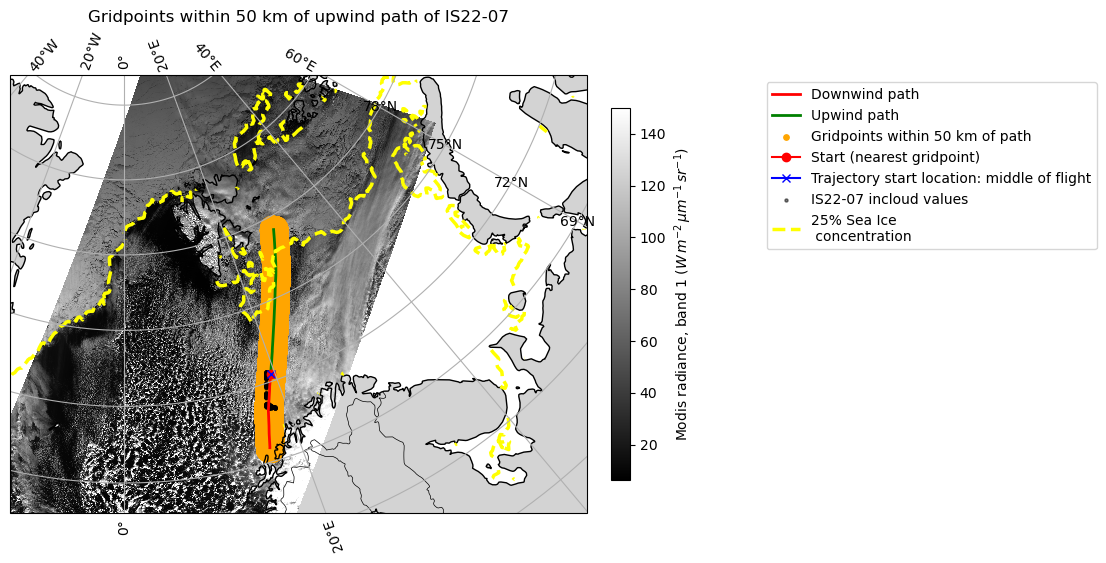

In [11]:
# Plot the path on the map

proj = ccrs.NorthPolarStereo()
fig, ax = plt.subplots(subplot_kw={"projection": proj}, figsize=(8, 8))

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Path
ax.plot(
    u_lons_path, u_lats_path,
    color="red", linestyle="-", linewidth=2,
    transform=ccrs.PlateCarree(),
    label="Downwind path",
)
ax.plot(
    d_lons_path, d_lats_path,
    color="green", linestyle="-", linewidth=2,
    transform=ccrs.PlateCarree(),
    label="Upwind path",
)
# add modis image
b = ax.pcolormesh(ds_modis_i.lon, ds_modis_i.lat, ds_modis_i.radiance.isel(band=0), transform=ccrs.PlateCarree(), cmap="gray", vmax=150,zorder=0)
cbar = fig.colorbar(b, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label(r'Modis radiance, band 1 ($W\,m^{-2}\,\mu m^{-1}\,sr^{-1}$)')

# Nearby gridpoints
ax.scatter(
    near_lons, near_lats,
    s=15, color="orange",
    transform=ccrs.PlateCarree(),
    label=f"Gridpoints within {radius_km:.0f} km of path",
)

# Starting & central point
ax.plot(
    u_lons_path[0], u_lats_path[0],
    marker="o", color="red", markersize=6,
    transform=ccrs.PlateCarree(),
    label="Start (nearest gridpoint)",
)
ax.plot(
    central_lon, central_lat,
    marker="x", color="blue", markersize=6,
    transform=ccrs.PlateCarree(),
    label=f"Trajectory start location: {central_name} of flight",
)

# Plot the flight track
ax.scatter(flight_ds.lon, flight_ds.lat, color="k", s=5, alpha = 0.5, marker="o",
            transform=ccrs.PlateCarree(), label=f"{flight} incloud values")

# add sea ice concentration
ax.contour(sic_ds['lon'],sic_ds['lat'],sic_ds['sic'], transform=ccrs.PlateCarree(),levels=[25.], colors='yellow', linestyles='dashed', linewidths=2.5)
contour_legend = mlines.Line2D([], [], color='yellow',linestyle='--', linewidth=2.5, label='25% Sea Ice \n concentration')


ax.legend()
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles+[contour_legend],bbox_to_anchor=(1.3, 1), loc="upper left")
        
lon_min = float(model["XLONG"].min())
lon_max = float(model["XLONG"].max())
lat_min = float(model["XLAT"].min())
lat_max = float(model["XLAT"].max())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.gridlines(draw_labels=True)
ax.set_title(f"Gridpoints within {radius_km:.0f} km of upwind path of {flight}")

#plt.show()
savefile = f'trajectory_curtain{flight}.png'
plt.savefig(savefile, dpi=300, bbox_inches='tight')

## Select model dataset from the path/ gridpoint area

TODO: 
- Only line OK
- Gridpoint area

In [11]:
# sanity check: do these match near_lats / near_lons?
#check_lats = model['XLAT'].values[i_arr, j_arr] #these two for nearby points
#check_lons = model['XLONG'].values[i_arr, j_arr] 
check_lats = model['XLAT'].values[i_arr_path, j_arr_path] # These two for on path
check_lons = model['XLONG'].values[i_arr_path, j_arr_path]

# these should be equal (nearby points)
#print(check_lats, near_lats)
#print(check_lons, near_lons)

# these should be equal (on path)
print(check_lats[-10:])
print(lats_path[-10:])
print(check_lons[10:20])
print(lons_path[10:20])


[77.403625 77.41261  77.42159  77.42951  77.43849  77.44747  77.45538
 77.46436  77.47334  77.47227 ]
[77.40346  77.41161  77.41976  77.4279   77.43605  77.44419  77.452324
 77.460464 77.4686   77.47672 ]
[16.689667 16.687263 16.68486  16.707855 16.705452 16.703049 16.726082
 16.723694 16.721298 16.746758]
[16.678019 16.68469  16.691631 16.698795 16.706026 16.712984 16.719166
 16.724667 16.729801 16.7348  ]


In [12]:

# select the subset of model data corresponding to the area defined by get_nearby_points_along_path
x_indices = xr.DataArray(i_arr, dims="points")
y_indices = xr.DataArray(j_arr, dims="points")
subset_area = model.isel(south_north=x_indices, west_east=y_indices)

x_indices = xr.DataArray(i_arr_path, dims="points")
y_indices = xr.DataArray(j_arr_path, dims="points")
subset_path = model.isel(south_north=x_indices, west_east=y_indices)

Text(0.5, 1.0, 'Gridpoints within 50 km of upwind path of IS22-07')

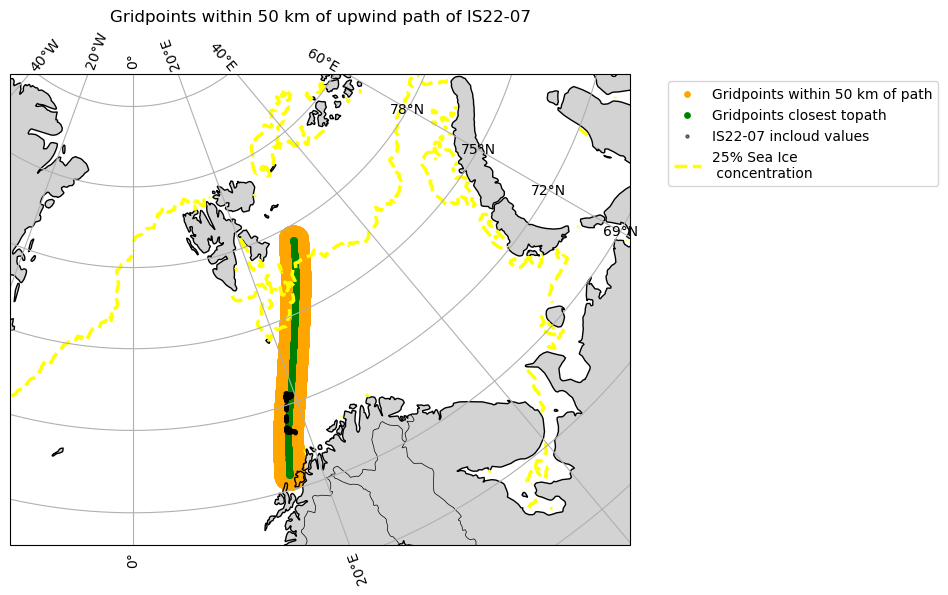

In [ ]:
# Plot the selected gridpoints on map
proj = ccrs.NorthPolarStereo()
fig, ax = plt.subplots(subplot_kw={"projection": proj}, figsize=(8, 8))

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Path

# Nearby gridpoints
ax.scatter(
    subset_area["XLONG"].values, subset_area["XLAT"].values,
    s=15, color="orange",
    transform=ccrs.PlateCarree(),
    label=f"Gridpoints within {radius_km:.0f} km of path",
)
ax.scatter(
    subset_path["XLONG"].values, subset_path["XLAT"].values,
    s=15, color="g",
    transform=ccrs.PlateCarree(),
    label=f"Gridpoints closest to windpath",
)

# Plot the flight track
ax.scatter(flight_ds.lon, flight_ds.lat, color="k", s=5, alpha = 0.5, marker="o",
            transform=ccrs.PlateCarree(), label=f"{flight} incloud values")

# add sea ice concentration
ax.contour(sic_ds['lon'],sic_ds['lat'],sic_ds['sic'], transform=ccrs.PlateCarree(),levels=[25.], colors='yellow', linestyles='dashed', linewidths=2.5)
contour_legend = mlines.Line2D([], [], color='yellow',linestyle='--', linewidth=2.5, label='25% Sea Ice \n concentration')


ax.legend()
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles+[contour_legend],bbox_to_anchor=(1.05, 1), loc="upper left")
        
lon_min = float(model["XLONG"].min())
lon_max = float(model["XLONG"].max())
lat_min = float(model["XLAT"].min())
lat_max = float(model["XLAT"].max())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.gridlines(draw_labels=True)
ax.set_title(f"Gridpoints within {radius_km:.0f} km of /n windpath connected to flight {flight}")


## Distance from sea ice and composite for single line

In [13]:
# Functions to add sea ice distance
def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between points in degrees.
    lat*, lon* can be numpy arrays (broadcastable).
    Returns distance in km.
    """
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (np.sin(dlat / 2.0) ** 2 +
         np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))

    # multiply by Earths radius (6371) to get distance in km
    dist_km = 6371.0 * c
    return dist_km

def add_signed_distance_to_ice_edge_along_path(ds_sea_ice, ds_path,seaice_var='seaice'):
    """
    Signed distance along a wind-aligned path to the nearest ice–ocean edge.

    Parameters
    ----------
    ds_sea_ice : xarray.Dataset or xarray.DataArray
        Sea-ice mask on a lat/lon grid.
        Must contain:
          - boolean variable `seaice_var` (True over ice, False over ocean),
          - coordinates `lat`, `lon`.
    ds_path : xarray.Dataset
        Path dataset with 1D coordinates:
          - XLAT(points)
          - XLONG(points)
    seaice_var : str
        Variable name of the sea-ice mask in ds_sea_ice (if Dataset).

    Returns
    -------
    ds_out : xarray.Dataset
        Copy of ds_path with:
          - over_ice(points) : bool, True where path point is over sea ice
          - distance_to_ice_edge(points) : float, km
            * positive over ocean  (distance to nearest ice–ocean edge)
            * negative over ice   (distance to nearest ice–ocean edge)
            * 0 at the edge itself
            * NaN if no edge exists along the path (all ice or all ocean).
    """

    # --- 1. Extract and flatten sea-ice mask and coordinates ---
    if isinstance(ds_sea_ice, xr.Dataset):
        mask = ds_sea_ice[seaice_var]
    else:
        mask = ds_sea_ice

    lat_grid = mask['lat'].values
    lon_grid = mask['lon'].values
    mask_vals = mask.values  # True over ice, False over ocean

    lat_flat = lat_grid.ravel()
    lon_flat = lon_grid.ravel()
    mask_flat = mask_vals.ravel()

    # Build KDTree for nearest-neighbor mask lookup
    proj_lon_flat = lon_flat * np.cos(np.radians(lat_flat))
    seaice_points_proj = np.column_stack((proj_lon_flat, lat_flat))
    tree = cKDTree(seaice_points_proj)

    # --- 2. Path coordinates ---
    lats_path = ds_path['XLAT'].values  # (points,)
    lons_path = ds_path['XLONG'].values

    proj_lons_path = lons_path * np.cos(np.radians(lats_path))
    path_points_proj = np.column_stack((proj_lons_path, lats_path))

    # --- 3. Determine whether each path point is over sea ice ---
    _, idx = tree.query(path_points_proj)
    over_ice = mask_flat[idx]  # bool, shape: (points,)

    # --- 4. Cumulative distance along the path ---
    d_segment = np.zeros_like(lats_path, dtype=float)
    if len(lats_path) > 1:
        d_segment[1:] = haversine_km(
            lats_path[:-1], lons_path[:-1],
            lats_path[1:],  lons_path[1:]
        )
    s_along = np.cumsum(d_segment)  # distance from point 0, km

    # --- 5. Locate ice–ocean edges along the path ---
    # Edge between i and i+1 where mask changes
    mask_change = over_ice[:-1] != over_ice[1:]
    edge_indices = np.where(mask_change)[0]  # edges between i and i+1

    if edge_indices.size == 0:
        # Path is entirely ice or entirely ocean: no edge along the path.
        distance_signed = np.full_like(lats_path, np.nan, dtype=float)
    else:
        # Position of each edge in km along the path:
        # put the edge halfway between the two points
        s_edges = 0.5 * (s_along[edge_indices] + s_along[edge_indices + 1])

        # Distance (unsigned) to nearest edge for each point
        # s_along[:, None] -> (points, 1); s_edges[None, :] -> (1, n_edges)
        dist_to_edges = np.abs(s_along[:, None] - s_edges[None, :])
        nearest_edge_dist = dist_to_edges.min(axis=1)  # (points,)

        # Sign: positive over ocean, negative over ice
        distance_signed = nearest_edge_dist.copy()
        distance_signed[over_ice] *= -1.0

    # --- 6. Attach to ds_path ---
    ds_out = ds_path.copy()

    ds_out['over_ice'] = xr.DataArray(
        over_ice,
        dims=['points'],
        coords={'points': ds_path['points']}
    )
    ds_out['over_ice'].attrs['description'] = 'True where path point is over sea ice'

    ds_out['distance_to_ice_edge'] = xr.DataArray(
        distance_signed,
        dims=['points'],
        coords={'points': ds_path['points']}
    )
    ds_out['distance_to_ice_edge'].attrs['units'] = 'km'
    ds_out['distance_to_ice_edge'].attrs['description'] = (
        'Signed distance along the path to the nearest ice–ocean edge; '
        'positive over ocean, negative over ice; NaN if no edge along path'
    )

    return ds_out

def dist_bin_setup(ds,dist_bin_size = 200):
     # --- Distance bin set up
    import numpy as np
   

    # Distances from sea ice for the model dataset
    dist_df = ds['distance_from_ice'].to_dataframe()

    # create distance bins based on the dist_bin_size and the max/min for the total dataset
    if dist_bin_size == 125:
        dist_bins = np.arange(dist_df['distance_from_ice'].min(),dist_df['distance_from_ice'].max()+125,125) # gives 11 distance bins of 125 km
        d_text ='dist125'
        
    elif dist_bin_size == 200:
        dist_bins = np.arange(dist_df['distance_from_ice'].min()-75,dist_df['distance_from_ice'].max()+175,200) # gives 8 distance bins of 200 km
        d_text ='dist200'
    elif dist_bin_size == 250:
        dist_bins = np.arange(dist_df['distance_from_ice'].min()-125,dist_df['distance_from_ice'].max()+175,250) # gives 6 distance bins of 250 km
        d_text ='dist250'
    elif dist_bin_size == 300:
        dist_bins = np.arange(dist_df['distance_from_ice'].min()-175,dist_df['distance_from_ice'].max()+175,300) # gives 6 distance bins of 300 km 
        d_text ='dist300'

    
    # digitize distances into bins
    dist_bin_indices = np.digitize(ds['distance_from_ice'], bins = dist_bins)
   
    ds = ds.assign_coords(dist_bin=('points', dist_bin_indices)) # on 'points' dimension

    # adjust indices to 0-based
    dist_bin_indices_adj = dist_bin_indices - 1

    # Only handle valid indices
    dist_bin_labels = np.full_like(dist_bin_indices_adj, fill_value=np.nan, dtype=float)
    valid_ind = dist_bin_indices_adj < len(dist_bins)
    dist_bin_labels[valid_ind] = dist_bins[dist_bin_indices_adj[valid_ind]]

    # Label data
    ds['dist_bin'].data = dist_bin_labels
    ds.coords['dist_bin'] = ds.coords['dist_bin'].astype(int)

    return ds, distbins, d_text


In [ ]:
# add distance from sea ice edge and binned distance
# for the path
subset_path_with_ice = add_signed_distance_to_ice_edge_along_path(ds_sea_ice, subset_path)
subset_path_with_ice, dist_bins, d_text = dist_bin_setup(subset_path_with_ice, dist_bin_size=200) # add distance bins for the composites
#subset_path_with_ice

# for the area around the path
subset_area_with_ice = add_signed_distance_to_ice_edge_along_path(ds_sea_ice, subset_area)
subset_area_with_ice, dist_bins, d_text = dist_bin_setup(subset_area_with_ice, dist_bin_size=200) # add distance bins for the composites
subset_area_with_ice

<xarray.Dataset> Size: 32MB
Dimensions:               (points: 959, west_east_stag: 1189,
                           south_north_stag: 1528, bottom_top_stag: 50)
Coordinates:
  * points                (points) int64 8kB 0 1 2 3 4 5 ... 954 955 956 957 958
    XLAT                  (points) float32 4kB 69.55 69.56 69.56 ... 77.47 77.47
    XLONG                 (points) float32 4kB 16.61 16.61 16.61 ... 28.91 28.95
    XLAT_V                (south_north_stag, points) float32 6MB ...
    XLONG_V               (south_north_stag, points) float32 6MB ...
    XLAT_U                (points, west_east_stag) float32 5MB ...
    XLONG_U               (points, west_east_stag) float32 5MB ...
    XTIME                 datetime64[ns] 8B ...
Dimensions without coordinates: west_east_stag, south_north_stag,
                                bottom_top_stag
Data variables: (12/21)
    U                     (points, west_east_stag) float32 5MB ...
    V                     (south_north_stag, points) float32 6MB ...
    T                     (points) float32 4kB ...
    P                     (points) float32 4kB ...
    PB                    (points) float32 4kB ...
    PH                    (bottom_top_stag, points) float32 192kB ...
    ...                    ...
    QNGRAUPEL             (points) float32 4kB ...
    QNRAIN                (points) float32 4kB ...
    OLR                   (points) float32 4kB ...
    wind_dir              (points) float32 4kB 17.95 17.88 17.82 ... 25.53 25.34
    over_ice              (points) bool 959B False False False ... True True
    distance_to_ice_edge  (points) float64 8kB 807.3 806.3 ... -132.0 -133.0
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.6.1 MODEL
    START_DATE:                      2022-03-21_12:00:00
    SIMULATION_START_DATE:           2022-03-21_12:00:00
    WEST-EAST_GRID_DIMENSION:        1189
    SOUTH-NORTH_GRID_DIMENSION:      1528
    BOTTOM-TOP_GRID_DIMENSION:       50
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

## Calculate the ice/liquid parameters for the model dataset

In [ ]:


m1 = subset_path_with_ice.copy()

# add phase to obs_all
# Phase determination: Mass based (Korolev et. al.2003)
# thresholds
th_ice = 0.1 
th_w = 0.9


# get height above mean sea level in meters
z_stag = (m1["PH"] + m1["PHB"])/9.81

z_mid = 0.5 * (z_stag.isel(bottom_top_stag=slice(0, -1)) +
               z_stag.isel(bottom_top_stag=slice(1,  None)))
m1['z_mid'] = z_mid.rename({"bottom_top_stag": "bottom_top"}) 


#calculate the ice/liquid parameters for the selected model domain
modcon_all, modcon = ice_liq_model(m1)

# squeeze the model data to remove the flight dimension (if it exists) for easier calculations and plotting
modcon['NICE'] = (modcon.QNICE + modcon.QNGRAUPEL + modcon.QNSNOW).squeeze()
modcon['MICE'] = (modcon.QICE + modcon.QGRAUP + modcon.QSNOW).squeeze())
modcon['MLIQ'] = (modcon.QCLOUD + modcon.QRAIN).squeeze()
modcon['SLF'] = (modcon['MLIQ']/(modcon['MICE']+modcon['MLIQ']))*100 # SLF in percent
# Phase determination: Mass based (Korolev et. al.2003)
# thresholds as for insitu
modcon['Phase']=xr.where(
    modcon['SLF'] < th_ice, 'ice',
    xr.where(modcon['SLF'] > th_w, 'liquid',
            xr.where(modcon['SLF'].isnull(),np.nan,'mixed')))
   

In [ ]:
# altitude bins for the composites
# the levels in the model is comparable to altitudes, but are not in distinct 200 m bins as we did for the insitu data.
# 
# from the old(insitu) code
# bin_labels = [300,600,900,1200,1500,1800,2100,2400,2700,3000,3300,3600,3900,4200,4500,4800]
# altitude_bins = np.unique(campaign_sel_model.altitude_bin)

# check how modcon looks like
print(modcon)



# Code below is code from model_composite, remove what is not needed

## Make the composite plots direct comparison
Model data is selected for the dataplots from the flights

In [ ]:
campaign_sel_model = modcon # change name to ease reusing code TODO: FIX LATER

In [ ]:
# Composite heatplot initiation values
var = 'NICE'

vars_to_plot = ['TWC','NICE','MICE','MLIQ','SLF'] # (alternatively: 'Phase' for phase composites)


# the stuff below can be put into a function:

# labels for the plot axes
obs_labels_dict = {
    'xax_lab':'Fetch (km)',
    'yax_lab':'Altitude (m)',
    'cbar_lab':f'Mean {var} ({campaign_sel_model[var].units})'
}

# Savefile name with the selected var
savefile = f'model_composite_{var}_incloud.png'


# calculate statistics dataframe  for var to use in heatplot
# statistics used already: mean, std, count
data_groupedx = campaign_sel_model[var].groupby('dist_bin')  # group by distance bin
data_groupedxy = data_groupedx.map(lambda group: group.groupby('altitude_bin').mean()) # group result altitude bin and take the mean
mean_df = data_groupedxy.to_dataframe().unstack()  # turn int dataframe
mean_df = mean_df.T.reset_index(level=0, drop = True).iloc[::-1] # - transpose to get altitude on y-axis - reset index and drop outer index(base_time)



In [ ]:
# Plot the composite heatplot: 

fig,ax = plt.subplots(figsize=(20, 10))

plot_heatmap_ax(mean_df, 
                obs_labels_dict, 
                ax, 
                mask_na= True, val=0, 
                annot_df = mean_df, 
                counts=False, ss=20, ncol=6, v_extend=12000, 
                altitude_bins=bin_labels)

ax.set_title(f"Model composite distribution: {var}")

plt.savefig(savefile, bbox_inches='tight')
print(f'Plot is saved to: {savefile}')

plt.show()

In [ ]:
# Joined all plots for one day
fig, ax = plt.subplots(3,2, figsize=(25, 20))

js=13

# --- The water content plots
# TWC
plot_heatmap_ax(cdnc_mean_df, cdnc_lab_dict, ax[0,0], mask_na=True, col='Grey', ss=js, ncol=5, v_extend=50, altitude_bins=altitude_bins)
ax[0,0].set_title('(a)', loc='left',fontdict={'fontsize': ss})

# MICE
plot_heatmap_ax(ed_meandiff_df, ed_labels_dict, ax[1,0], mask_na= True, col=cmap_ed,ss=js, ticks=t_ed,v_extend=20, altitude_bins=altitude_bins)
ax[1,0].set_title('(c)', loc='left',fontdict={'fontsize': ss})

# MLIQ
plot_heatmap_ax(lwc_mean_df, lwc_lab_dict, ax[2,0], mask_na=True, val=2, ncol=5, ss=js,v_extend=0.2, altitude_bins=altitude_bins)
ax[2,0].set_title('(e)', loc='left',fontdict={'fontsize': ss})

# --- SLF and number concentration plots
# SLF
plot_heatmap_ax(icnc_mean_df, icnc_lab_dict, ax[0,1], mask_na=True,col='Grey',ncol=5,ss=js, v_extend=15, altitude_bins=altitude_bins)
ax[0,1].set_title('(b)', loc='left',fontdict={'fontsize': ss})

# NICE
plot_heatmap_ax(mvd_meandiff_df, cip_lab_dict, ax[1,1], mask_na= True, col=cmap_mvd,ss=js, ticks=t_mvd, altitude_bins=altitude_bins)
ax[1,1].set_title('(d)', loc='left',fontdict={'fontsize': ss})


savefile = f'model_composite_all_{flight}.png'
plt.savefig(savefile, bbox_inches='tight', dpi=300)
